# Course tools and Python foundations

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/foundations/01-course-tools.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

This notebook introduces the small set of Python tools used throughout the course. It is not a comprehensive Python tutorial: the goal is to be comfortable loading, inspecting, selecting, filtering, and plotting engineering data.

**Learning objectives**

- Use NumPy arrays for basic numerical calculations.
- Load a public dataset into a Pandas DataFrame.
- Select columns and filter rows using clear, readable code.
- Make and interpret a simple engineering-data plot.

## 1. Import the Python libraries

The next cell demonstrates how to import a Python library.

`import numpy as np` makes the NumPy library available in this notebook. The `as` keyword assigns the short alias `np` to NumPy's namespace, so we can write `np.array(...)` instead of the longer `numpy.array(...)`. Using `np` is a common convention in scientific Python.

In [1]:
# Import NumPy first: it is the numerical-array tool used in this section.
import numpy as np

## 2. Numerical arrays

A NumPy array stores a collection of numerical values. Array operations act element-by-element, which makes calculations compact and readable.

In [2]:
# Store repeated temperature measurements in a one-dimensional numerical array.
temperatures_c = np.array([15.2, 18.7, 21.4, 24.1])
# NumPy applies this unit conversion to every element of the array at once.
temperatures_k = temperatures_c + 273.15

print("Temperatures in K:", temperatures_k)
print(f"Mean temperature: {temperatures_c.mean():.1f} °C")
print(f"Range: {temperatures_c.min():.1f}–{temperatures_c.max():.1f} °C")

Temperatures in K: [288.35 291.85 294.55 297.25]
Mean temperature: 19.9 °C
Range: 15.2–24.1 °C


The array is useful for a single quantity observed repeatedly. A table with many named variables is better represented by a Pandas **DataFrame**.

Compared with a native Python list, a NumPy array is designed for numerical work. It supports vectorized calculations—such as adding `273.15` to every temperature—in one clear operation, stores values efficiently, and is much faster for the large arrays used in data analysis and machine learning.

## 3. Load the course dataset

The Gas Turbine CO and NOx Emissions dataset records the operation of a gas turbine between 2011 and 2015. It combines ambient conditions, turbine sensor measurements, energy yield, and two emissions outcomes: carbon monoxide (CO) and nitrogen oxides (NOx).

Each row represents one hourly observation of the system: the measured operating and environmental conditions during that hour, together with the emissions observed at that time. This course returns to the same dataset repeatedly so that the modeling choices remain connected to a physical system.

The original data and documentation are available from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/551/gas+turbine+co+and+nox+emission+data+set).

In [3]:
# Pandas represents a table with named columns as a DataFrame.
import pandas as pd
from pathlib import Path
from urllib.request import urlretrieve

# Use the committed course version so everyone analyzes the same data.
DATA_URL = (
    "https://raw.githubusercontent.com/changyaochen/MECE4520/master/"
    "site/data/gas-turbine-course.csv"
)
# Prefer a local copy; otherwise download it when this notebook runs independently.
data_path = next(
    (path for path in [
        Path("../data/gas-turbine-course.csv"),
        Path("site/data/gas-turbine-course.csv"),
        Path("gas-turbine-course.csv")]
        if path.exists()
    ),
    Path("gas-turbine-course.csv"),
)
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)
data = pd.read_csv(data_path)

# Inspect the dataset size before selecting variables or fitting a model.
print(f"Rows: {len(data):,}")
print(f"Columns: {data.shape[1]}")
data.head()

Rows: 36,733
Columns: 12


,campaign_year,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,2011,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952
1,2011,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377
2,2011,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776
3,2011,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505
4,2011,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028


A good first habit is to inspect the column names and units before modeling. This data dictionary identifies every column in the course dataset.

| Variable | Meaning |
|:--|:--|
| `AT` | Ambient temperature (°C) |
| `AP` | Ambient pressure (mbar) |
| `AH` | Ambient humidity (%) |
| `AFDP` | Air filter differential pressure (mbar) |
| `GTEP` | Gas turbine exhaust pressure (mbar) |
| `TIT` | Turbine inlet temperature (°C) |
| `TAT` | Turbine after temperature (°C) |
| `TEY` | Turbine energy yield (MWh) |
| `CDP` | Compressor discharge pressure (mbar) |
| `CO` | Carbon monoxide emissions (mg/m³) |
| `NOX` | Nitrogen oxides emissions (mg/m³) |

## 4. Select and filter data

Data analysis often begins with two simple operations: selecting the **columns** (variables) relevant to a question and filtering the **rows** (observations) that meet a condition. The next cell demonstrates both operations on the gas-turbine data.

In [4]:
# Select a small set of ambient, turbine, and emissions variables for inspection.
selected = data[["AT", "TIT", "TEY", "CO", "NOX"]]
# Use the median to divide the observations into relatively warmer and cooler conditions.
warm_conditions = selected[selected["AT"] > selected["AT"].median()]

print("Selected variables:")
display(selected.head())
print(f"Rows above the median ambient temperature: {len(warm_conditions):,}")
warm_conditions.describe().loc[["mean", "std", "min", "max"]]

Selected variables:


,AT,TIT,TEY,CO,NOX
0,4.5878,1086.2,134.67,0.32663,81.952
1,4.2932,1086.1,134.67,0.44784,82.377
2,3.9045,1086.5,135.10,0.45144,83.776
3,3.7436,1086.5,135.03,0.23107,82.505
4,3.7516,1085.9,134.67,0.26747,82.028


Rows above the median ambient temperature: 18,365


,AT,TIT,TEY,CO,NOX
mean,24.005367,1083.897964,132.012501,2.057256,59.22925
std,3.905948,15.765051,13.316517,1.602460,7.97456
min,17.802000,1024.800000,100.040000,0.001594,25.90500
max,37.103000,1100.900000,160.370000,37.746000,119.91000


## 5. Make a first plot

A scatter plot helps us inspect whether two variables move together. Each point below is one hourly observation. We draw only a random subset so the plot remains readable.

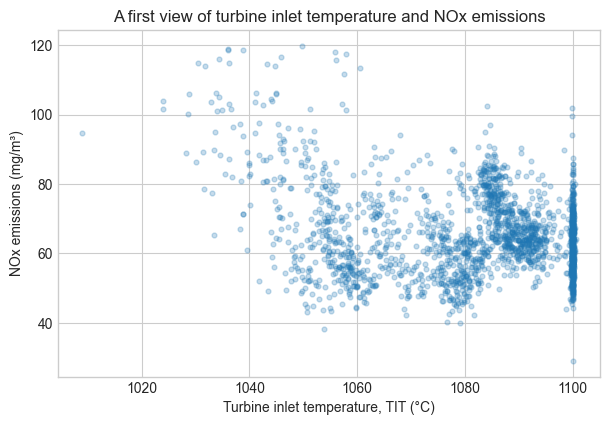

In [5]:
# Import Matplotlib only when we are ready to make a figure.
import matplotlib.pyplot as plt

# Use a readable plotting style for the exploratory figure below.
plt.style.use("seaborn-v0_8-whitegrid")

# Plot a reproducible subset so overlapping points do not hide the overall pattern.
# This is useful for large datasets.
plot_data = data.sample(n=2_000, random_state=4520)

# Each point represents one hourly turbine observation.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(plot_data["TIT"], plot_data["NOX"], alpha=0.25, s=12)
ax.set(
    xlabel="Turbine inlet temperature, TIT (°C)",
    ylabel="NOx emissions (mg/m³)",
    title="A first view of turbine inlet temperature and NOx emissions",
)
plt.show()

## Check-in

1. Change the plotting code to use `AT` or `TEY` on the horizontal axis. What pattern do you see?
2. What is one question you would ask before interpreting this plot as a causal relationship?
3. In one sentence, explain the difference between a NumPy array and a Pandas DataFrame.

Keep your answers in your own notes. We will build on this dataset in the next notebook.

[Return to the Foundations page](index.qmd)